# 2409106002 - Renaya Putri Alika - POSTTEST_1 - Kecerdasan Buatan
## Tema: Campus Student Placement 
### Faktor-Faktor yang Mempengaruhi Penempatan Kerja Mahasiswa di Kampus


Notebook ini berisi eksplorasi data (EDA) terhadap dataset **Factors Affecting Campus Placement** yang diambil dari Kaggle: https://www.kaggle.com/datasets/benroshan/factors-affecting-campus-placement/data

Dataset ini berisi data akademik dan non-akademik mahasiswa (nilai SMP/SMA, nilai kuliah, pengalaman kerja, nilai tes kerja, dsb) yang digunakan untuk melihat faktor apa saja yang memengaruhi status penempatan kerja (placement) mahasiswa setelah lulus, beserta besaran gaji (salary) yang diterima jika mahasiswa tersebut berhasil ditempatkan bekerja.

Dataset terdiri dari **215 baris (record)** dan **15 kolom (atribut)**, dengan rincian atribut sebagai berikut:

| Kolom | Keterangan |
|---|---|
| sl_no | Nomor urut data |
| gender | Jenis kelamin (M/F) |
| ssc_p | Nilai ujian SMP (%) |
| ssc_b | Jenis penyelenggara pendidikan SMP (Central/Others) |
| hsc_p | Nilai ujian SMA (%) |
| hsc_b | Jenis penyelenggara pendidikan SMA (Central/Others) |
| hsc_s | Jurusan saat SMA (Science/Commerce/Arts) |
| degree_p | Nilai kelulusan S1 (%) |
| degree_t | Bidang studi S1 (Sci&Tech/Comm&Mgmt/Others) |
| workex | Pengalaman kerja sebelumnya (Yes/No) |
| etest_p | Nilai tes kerja (employability test) (%) |
| specialisation | Spesialisasi MBA (Mkt&HR/Mkt&Fin) |
| mba_p | Nilai MBA (%) |
| status | Status penempatan kerja (Placed/Not Placed) |
| salary | Gaji yang diterima (hanya terisi jika status = Placed) |


## 1. Memuat Dataset
Dataset diunduh langsung dari Kaggle menggunakan library `kagglehub`, kemudian dibaca menggunakan `pandas`.

In [1]:
!pip install kagglehub -q # Menginstal library kagglehub untuk mengunduh dataset langsung dari Kaggle

In [2]:
import kagglehub
import os

# Mengunduh dataset 'Factors Affecting Campus Placement' dari Kaggle
path = kagglehub.dataset_download("benroshan/factors-affecting-campus-placement")
print("Dataset tersimpan di:", path)
print("Isi folder:", os.listdir(path))

/Users/renayaputri81gmail.com/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 4.51k/4.51k [00:00<00:00, 5.51MB/s]

Extracting files...
Dataset tersimpan di: /Users/renayaputri81gmail.com/.cache/kagglehub/datasets/benroshan/factors-affecting-campus-placement/versions/1
Isi folder: ['Placement_Data_Full_Class.csv']


Catatan: Jika perintah `kagglehub.dataset_download` gagal dijalankan (misalnya karena belum login ke akun Kaggle di Colab), dataset bisa diunduh manual dari link Kaggle di atas lalu diunggah ke Colab menggunakan `files.upload()`, kemudian sesuaikan nama file CSV pada baris `pd.read_csv()` di bawah ini.

In [3]:
import pandas as pd

# Nama file csv di dalam dataset Kaggle ini adalah 'Placement_Data_Full_Class.csv'
file_csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]
dataFrame = pd.read_csv(os.path.join(path, file_csv)) # Memuat dataset ke dalam DataFrame pandas
dataFrame.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## 2. Informasi Umum Dataset
Bagian ini menampilkan jumlah record, jumlah atribut, nama-nama atribut, tipe data setiap atribut, serta jumlah atribut yang bertipe angka (numerik).

In [4]:
dataFrame.info() # Menampilkan jumlah record, jumlah atribut, nama atribut, tipe data, dan non-null count tiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [5]:
jumlah_record, jumlah_atribut = dataFrame.shape
print(f"Jumlah record  : {jumlah_record}")
print(f"Jumlah atribut : {jumlah_atribut}")
print(f"Nama atribut   : {list(dataFrame.columns)}")

Jumlah record  : 215
Jumlah atribut : 15
Nama atribut   : ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


In [6]:
# Memisahkan atribut berdasarkan tipe data
atribut_numerik = dataFrame.select_dtypes(include=['int64', 'float64']).columns.tolist()
atribut_kategorikal = dataFrame.select_dtypes(include=['object']).columns.tolist()

print(f"Jumlah atribut bertipe angka (numerik) : {len(atribut_numerik)}")
print(f"Nama atribut numerik                   : {atribut_numerik}")
print()
print(f"Jumlah atribut bertipe object (kategorikal) : {len(atribut_kategorikal)}")
print(f"Nama atribut kategorikal                    : {atribut_kategorikal}")

Jumlah atribut bertipe angka (numerik) : 7
Nama atribut numerik                   : ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Jumlah atribut bertipe object (kategorikal) : 8
Nama atribut kategorikal                    : ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_12471/3202720103.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  atribut_kategorikal = dataFrame.select_dtypes(include=['object']).columns.tolist()


## 3. Statistik Deskriptif Atribut Numerik
Menampilkan rata-rata (mean), standar deviasi (std), nilai minimum, nilai maksimum, kuartil 1 (Q1 / 25%), kuartil 2 (Q2 / median / 50%), dan kuartil 3 (Q3 / 75%) untuk setiap atribut bertipe angka. Perlu diperhatikan bahwa kolom `salary` memiliki nilai kosong (NaN) pada mahasiswa yang berstatus `Not Placed`, sehingga jumlah data (count) yang dihitung untuk kolom tersebut lebih sedikit.

In [7]:
statistik_deskriptif = dataFrame[atribut_numerik].describe().T
# describe() secara otomatis menghitung count, mean, std, min, 25% (Q1), 50% (Q2), 75% (Q3), dan max
statistik_deskriptif[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
sl_no,108.000000,62.209324,1.00,54.500,108.0,161.500,215.00
ssc_p,67.303395,10.827205,40.89,60.600,67.0,75.700,89.40
hsc_p,66.333163,10.897509,37.00,60.900,65.0,73.000,97.70
degree_p,66.370186,7.358743,50.00,61.000,66.0,72.000,91.00
etest_p,72.100558,13.275956,50.00,60.000,71.0,83.500,98.00
mba_p,62.278186,5.833385,51.21,57.945,62.0,66.255,77.89
salary,288655.405405,93457.452420,200000.00,240000.000,265000.0,300000.000,940000.00


## 4. 10 Record Pertama (Atribut Numerik)
Menampilkan 10 baris data pertama, hanya untuk kolom-kolom yang bertipe angka.

In [8]:
dataFrame[atribut_numerik].head(10)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,1,67.00,91.00,58.00,55.00,58.80,270000.0
1,2,79.33,78.33,77.48,86.50,66.28,200000.0
2,3,65.00,68.00,64.00,75.00,57.80,250000.0
3,4,56.00,52.00,52.00,66.00,59.43,NaN
4,5,85.80,73.60,73.30,96.80,55.50,425000.0
5,6,55.00,49.80,67.25,55.00,51.58,NaN
6,7,46.00,49.20,79.00,74.28,53.29,NaN
7,8,82.00,64.00,66.00,67.00,62.14,252000.0
8,9,73.00,79.00,72.00,91.34,61.29,231000.0
9,10,58.00,70.00,61.00,54.00,52.21,NaN


## 5. Jumlah Label pada Setiap Atribut Kategorikal (Object)
Menampilkan jumlah label/kategori unik untuk setiap atribut bertipe object, beserta rincian jumlah data pada masing-masing label.

In [9]:
for kolom in atribut_kategorikal:
    jumlah_label = dataFrame[kolom].nunique()
    print(f"Atribut '{kolom}' memiliki {jumlah_label} label:")
    print(dataFrame[kolom].value_counts())
    print("-" * 40)

Atribut 'gender' memiliki 2 label:
gender
M    139
F     76
Name: count, dtype: int64
----------------------------------------
Atribut 'ssc_b' memiliki 2 label:
ssc_b
Central    116
Others      99
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_b' memiliki 2 label:
hsc_b
Others     131
Central     84
Name: count, dtype: int64
----------------------------------------
Atribut 'hsc_s' memiliki 3 label:
hsc_s
Commerce    113
Science      91
Arts         11
Name: count, dtype: int64
----------------------------------------
Atribut 'degree_t' memiliki 3 label:
degree_t
Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: count, dtype: int64
----------------------------------------
Atribut 'workex' memiliki 2 label:
workex
No     141
Yes     74
Name: count, dtype: int64
----------------------------------------
Atribut 'specialisation' memiliki 2 label:
specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64
-----------------------------------

In [10]:
# Ringkasan jumlah label tiap atribut kategorikal dalam bentuk tabel
ringkasan_label = pd.DataFrame({
    'Atribut': atribut_kategorikal,
    'Jumlah Label': [dataFrame[kolom].nunique() for kolom in atribut_kategorikal]
})
ringkasan_label

,Atribut,Jumlah Label
0,gender,2
1,ssc_b,2
2,hsc_b,2
3,hsc_s,3
4,degree_t,3
5,workex,2
6,specialisation,2
7,status,2


## 6. Visualisasi Data
Berikut ditampilkan dua jenis grafik untuk membantu memahami sebaran dan pola pada dataset.

### 6.1 Histogram - Sebaran Nilai Akademik (Atribut Numerik)
Histogram digunakan untuk melihat sebaran (distribusi) dari atribut numerik seperti nilai SMP, SMA, kuliah, tes kerja, dan MBA. Grafik ini cocok digunakan karena atribut yang divisualisasikan bersifat kontinu (angka desimal/persentase).

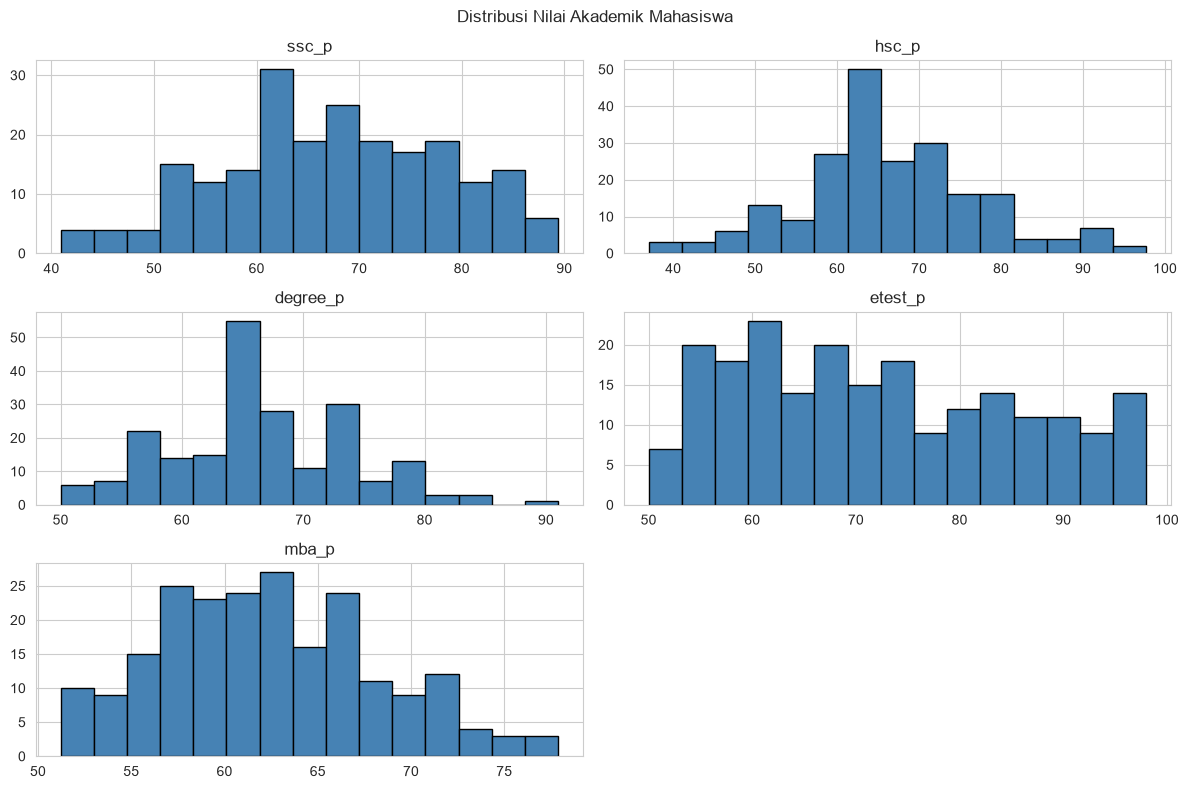

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

kolom_nilai = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
dataFrame[kolom_nilai].hist(figsize=(12, 8), bins=15, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Nilai Akademik Mahasiswa')
plt.tight_layout()
plt.show()

### 6.2 Bar Chart - Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja
Bar chart / count plot digunakan untuk melihat perbandingan jumlah mahasiswa yang berhasil ditempatkan kerja (`Placed`) dan yang tidak (`Not Placed`). Grafik ini cocok karena atribut `status` bersifat kategorikal (bukan angka kontinu).

/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_12471/3427953330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataFrame, x='status', palette='Set2')


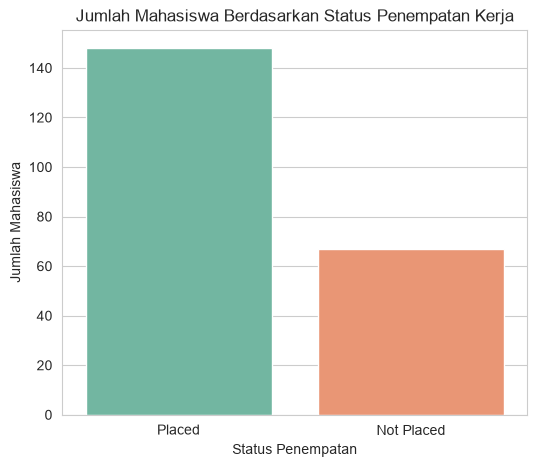

In [12]:
plt.figure(figsize=(6, 5))
sns.countplot(data=dataFrame, x='status', palette='Set2')
plt.title('Jumlah Mahasiswa Berdasarkan Status Penempatan Kerja')
plt.xlabel('Status Penempatan')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

### 6.3 (Tambahan) Boxplot - Nilai MBA Berdasarkan Status Penempatan
Sebagai tambahan eksplorasi, boxplot berikut membandingkan sebaran nilai MBA (`mba_p`) antara mahasiswa yang ditempatkan kerja dan yang tidak, untuk melihat apakah nilai MBA berpengaruh terhadap peluang penempatan kerja.

/var/folders/3w/15hcpsv56lxff6t0n9z8q34w0000gn/T/ipykernel_12471/1376685260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataFrame, x='status', y='mba_p', palette='Set3')


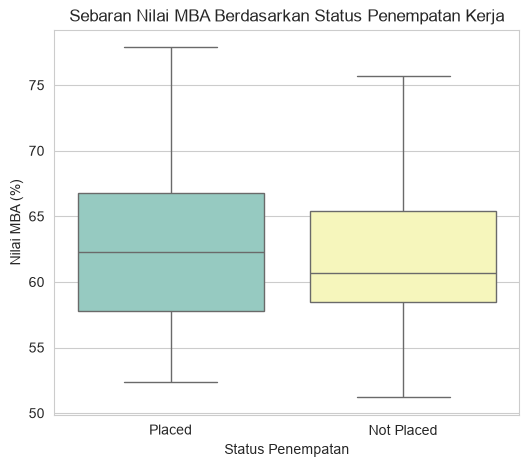

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=dataFrame, x='status', y='mba_p', palette='Set3')
plt.title('Sebaran Nilai MBA Berdasarkan Status Penempatan Kerja')
plt.xlabel('Status Penempatan')
plt.ylabel('Nilai MBA (%)')
plt.show()

## 7. Korelasi Antar Atribut Numerik (Heatmap)
Heatmap berikut menampilkan nilai korelasi antar atribut numerik dalam dataset. Nilai korelasi berkisar dari -1 hingga 1: semakin mendekati 1 artinya semakin kuat hubungan positif, semakin mendekati -1 artinya semakin kuat hubungan negatif, dan mendekati 0 artinya hampir tidak ada hubungan linear.

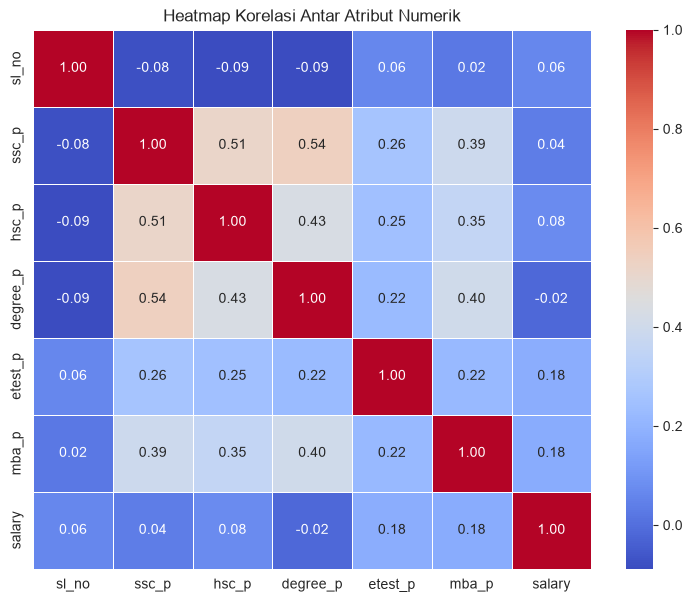

In [14]:
matriks_korelasi = dataFrame[atribut_numerik].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Atribut Numerik')
plt.show()

Dari heatmap di atas dapat dilihat pola korelasi antar nilai akademik mahasiswa, misalnya apakah nilai SMP (`ssc_p`), SMA (`hsc_p`), dan nilai kuliah (`degree_p`) saling berkaitan satu sama lain, serta seberapa besar keterkaitannya dengan nilai tes kerja (`etest_p`) dan nilai MBA (`mba_p`).

## 8. Kesimpulan Sementara
Berdasarkan eksplorasi data di atas, dapat disimpulkan sementara bahwa:
1. Dataset terdiri dari 215 record dan 15 atribut, dengan 7 atribut bertipe numerik dan 8 atribut bertipe kategorikal (termasuk `status`).

2. Sebagian besar mahasiswa dalam dataset ini berstatus `Placed` (ditempatkan kerja).

3. Nilai-nilai akademik (SMP, SMA, kuliah, MBA) menunjukkan pola sebaran yang relatif normal (mendekati distribusi lonceng).

4. Perlu dilakukan analisis lebih lanjut untuk melihat atribut mana yang paling berpengaruh terhadap status penempatan kerja, misalnya      menggunakan model klasifikasi pada modul selanjutnya.